# Imports

In [11]:
# Automatically reloads modules before each cell execution, so code changes in library are always propogated.
#reload or load? _ext
%load_ext autoreload
%autoreload 2

%load_ext snakeviz

import networkx as nx
from networkx import MultiDiGraph
import osmnx as ox
import numpy as np
import pandas as pd
from difflib import SequenceMatcher
import copy


from graph_manager import GraphManager
import investigation
import plotting
import constants

ox.settings.useful_tags_way = [
    "bridge", "tunnel", "oneway", "lanes", "highway",
     "width", "name", "name:en", "bicycle", "cycleway"]

SEED = 72
SAMPLE_K = 1000

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The snakeviz extension is already loaded. To reload it, use:
  %reload_ext snakeviz


# Network setup

In [2]:
#NOTE the length attribute is given in meters
#You project not to fix lengths, but to make sure your geometry math (like areas or spatial intersections) makes sense in linear units.
#Simplify is used to significantly reduce the number of nodes, removing dead ends and combining nodes with no intersections
LOCATION = "Malta (island)"

my_graph = GraphManager(LOCATION)

Loading OSM networks for Malta (island)...
creating master graph network...
Adding elevation data.....
Imputing missing elevation values
Iteration 1: imputed 392 nodes
Iteration 2: imputed 90 nodes
Iteration 3: imputed 20 nodes
Iteration 4: imputed 6 nodes
Iteration 5: imputed 0 nodes
node elevation nan <class 'float'>
NOde246587560 elevation is problematic :/
NOde5243805554 elevation is problematic :/
NOde9068823240 elevation is problematic :/
node elevation 59.0 <class 'float'>


## Road type classification

In [3]:
my_graph.summarise_road_type_stats(my_graph.G_master)

Highway type counts:
residential: 39042
service: 15822
track: 10991
tertiary: 6150
secondary: 5330
non_motorised: 2848
trunk: 2122
primary: 1985
cycleway: 297
-------
bikeway classification type counts:
None: 82021
yes: 2183
designated: 317
no: 45
permissive: 14
permit: 4
private: 3
------
cycleway type counts:
None: 84299
no: 201
shared: 30
track: 21
shared_lane: 14
lane: 14
crossing: 8


In [4]:

print("Nodes:", my_graph.G_master.number_of_nodes())
print("Edges (total, counts parallel edges separately):", my_graph.G_master.number_of_edges())
print(my_graph.G_master.graph)

Nodes: 35755
Edges (total, counts parallel edges separately): 84587
{'created_date': '2025-11-14 10:49:20', 'created_with': 'OSMnx 2.0.5', 'crs': <Projected CRS: EPSG:32633>
Name: WGS 84 / UTM zone 33N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 12°E and 18°E, northern hemisphere between equator and 84°N, onshore and offshore. Austria. Bosnia and Herzegovina. Cameroon. Central African Republic. Chad. Congo. Croatia. Czechia. Democratic Republic of the Congo (Zaire). Gabon. Germany. Hungary. Italy. Libya. Malta. Niger. Nigeria. Norway. Poland. San Marino. Slovakia. Slovenia. Svalbard. Sweden. Vatican City State.
- bounds: (12.0, 0.0, 18.0, 84.0)
Coordinate Operation:
- name: UTM zone 33N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
, 'simplified': True}


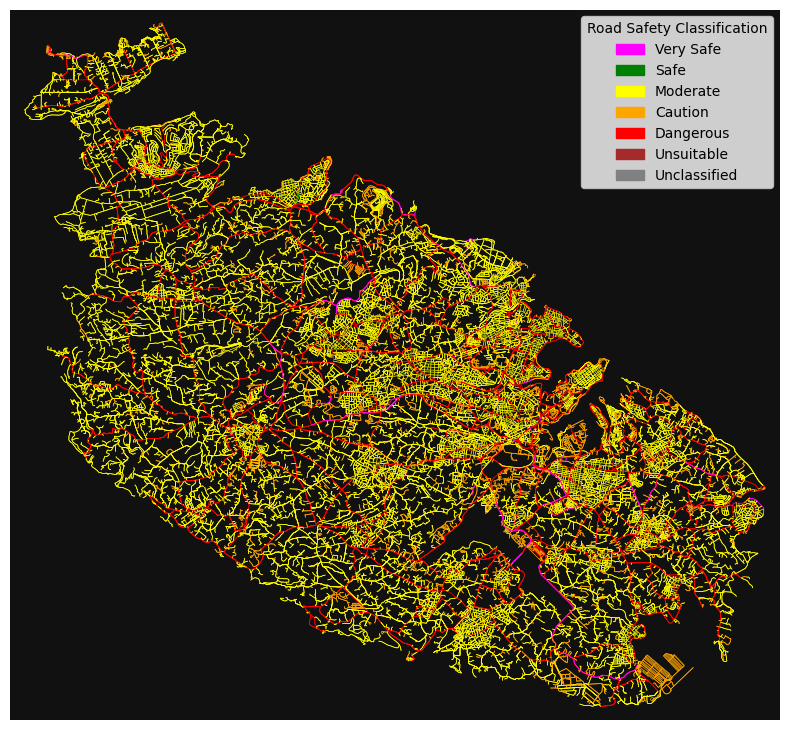

In [5]:
plotting.plot_road_classification(my_graph.G_master)

In [6]:
"""investigation.analyze_parallel_edges(my_graph.G_master)
investigation.compare_parallel_edges(my_graph.G_master)
investigation.plot_parallel_edges(my_graph.G_master)
print("-----")"""

'investigation.analyze_parallel_edges(my_graph.G_master)\ninvestigation.compare_parallel_edges(my_graph.G_master)\ninvestigation.plot_parallel_edges(my_graph.G_master)\nprint("-----")'

## Topology

Fetched elevations for 35755 / 35755 nodes


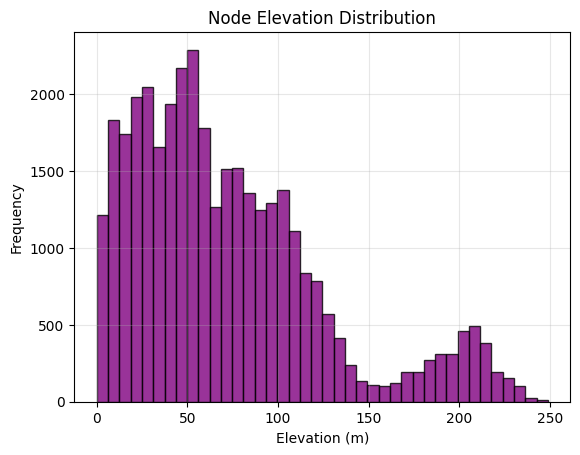

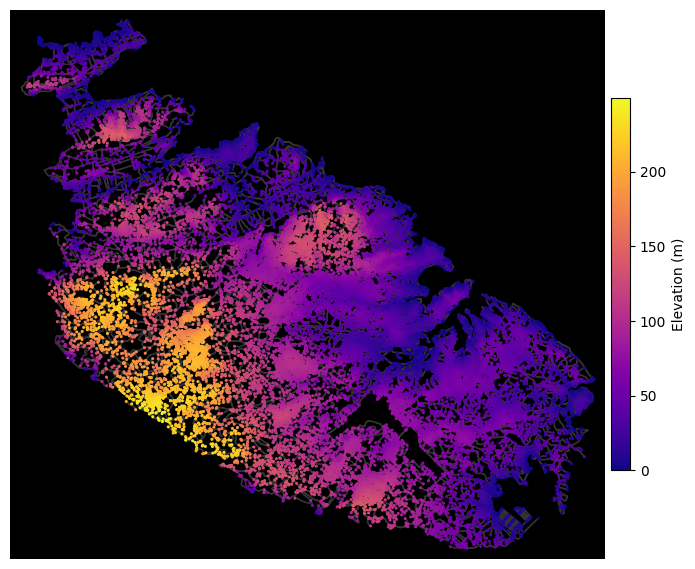

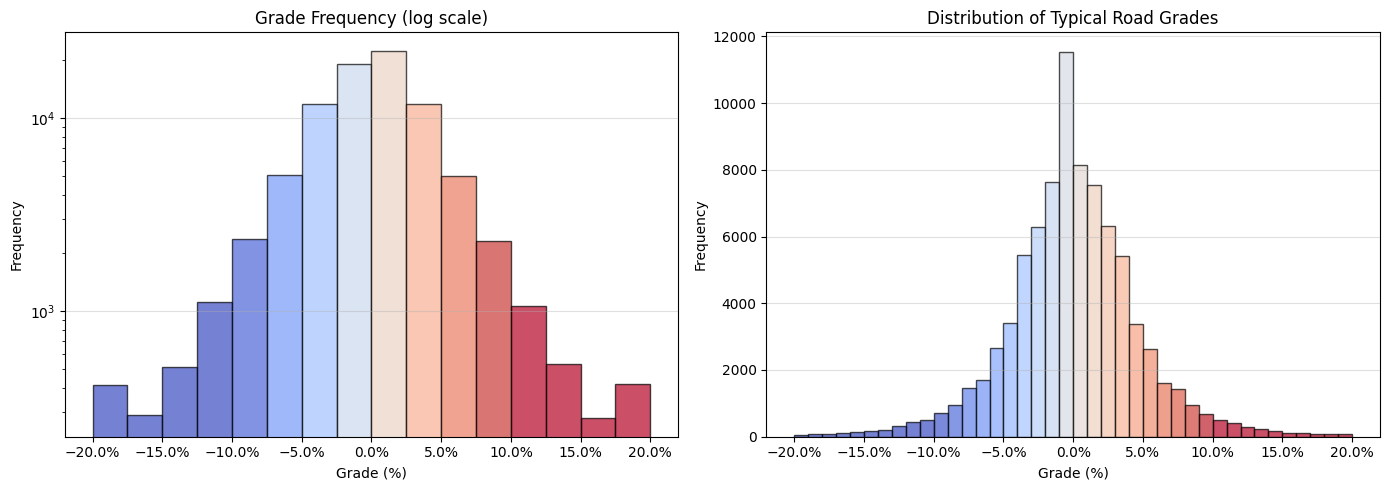

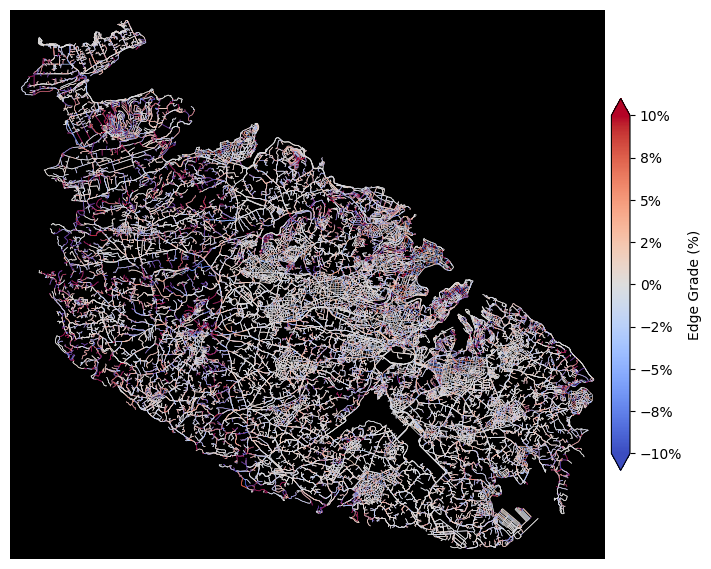

In [7]:
plotting.plot_elevation(my_graph.G_master)
plotting.plot_grades(my_graph.G_master)

## Network statistics

In [8]:
"""# what sized area does our network cover in square meters?
bike_nodes_proj = ox.convert.graph_to_gdfs(my_graph.G_master, edges=False) #Get only nodes
graph_area_m = bike_nodes_proj.union_all().convex_hull.area
# show some basic stats about the network
stats = ox.stats.basic_stats(my_graph.G_master, area=graph_area_m, clean_int_tol=15)"""

'# what sized area does our network cover in square meters?\nbike_nodes_proj = ox.convert.graph_to_gdfs(my_graph.G_master, edges=False) #Get only nodes\ngraph_area_m = bike_nodes_proj.union_all().convex_hull.area\n# show some basic stats about the network\nstats = ox.stats.basic_stats(my_graph.G_master, area=graph_area_m, clean_int_tol=15)'

In [9]:
edge_keys = set()
for u,v,data in my_graph.G_master.edges(data=True):
    edge_keys.update(data.keys())
print(edge_keys)

{'name:en', 'safety', 'grade', 'name', 'oneway', 'bike_allowed', 'bridge', 'highway', 'car_allowed', 'geometry', 'bicycle', 'risk_factor', 'car_lanes', 'tunnel', 'length', 'osmid', 'reversed', 'width', 'grade_abs', 'bike_lanes', 'cycleway'}


# Generating city level subgraphs

In [25]:
# 1. Get boundary GeoDataFrame for localities (e.g., admin_level = 8)
# Use geocode_to_gdf for each locality (or list of names)
#locs_gdf = ox.geocode_to_gdf(constants.cities)
gdf_localities = ox.features.features_from_place(
    "Malta (Island)",
    tags={"boundary": "administrative", "admin_level": "8"}
)

gdf_localities = gdf_localities[["name", "admin_level","geometry"]]
gdf_localities = gdf_localities[gdf_localities['admin_level'] == "8"]
gdf_localities = gdf_localities.dropna()
gdf_localities = gdf_localities.drop_duplicates(subset=['name'])
# Inspect results

print("Number of localities:", len(gdf_localities))
display(gdf_localities)

Number of localities: 54


name admin_level  \
element  id                                       
relation 6172198           Il-Birgu           8   
         6172199         Tas-Sliema           8   
         6172218           L-Imġarr           8   
         6181422        Il-Mellieħa           8   
         7510547          Il-Ħamrun           8   
         7510548       Santa Venera           8   
         7510549           L-Imdina           8   
         7510550         Ħal Balzan           8   
         7510551           Ħ'Attard           8   
         7510552         Ħaż-Żebbuġ           8   
         7510553           Ħal Safi           8   
         7510554         Ħal Kirkop           8   
         7510555          L-Imqabba           8   
         7510556          Ħal Qormi           8   
         7510557           Il-Gudja           8   
         7510558       Santa Luċija           8   
         7510559        Ħal Tarxien           8   
         7510560           Il-Fgura           8   
         7510561          Iż-Żejtun           8   
         7510562         Ħal Għaxaq           8   
         7510563           Ħal Luqa           8   
         7510564          L-Imtarfa           8   
         7510565           Ir-Rabat           8   
         7510566         Ħad-Dingli           8   
         7510567        Is-Siġġiewi           8   
         7510568          Il-Qrendi           8   
         7510569         Iż-Żurrieq           8   
         7510570         Birżebbuġa           8   
         7510571         Marsaxlokk           8   
         7510572      Wied il-Għajn           8   
         7510573         Ħaż-Żabbar           8   
         7510574         Ix-Xgħajra           8   
         7510575         Il-Kalkara           8   
         7510576             Bormla           8   
         7510577         Raħal Ġdid           8   
         7510578             L-Isla           8   
         7510579           Il-Marsa           8   
         7510580   Il-Belt Valletta           8   
         7510581         Il-Furjana           8   
         7510582          Tal-Pietà           8   
         7510583          Ta' Xbiex           8   
         7510584           L-Imsida           8   
         7510585         Birkirkara           8   
         7510586            L-Iklin           8   
         7510587          San Ġwann           8   
         7510588           Il-Gżira           8   
         7510589         San Ġiljan           8   
         7510590           Pembroke           8   
         7510591          Is-Swieqi           8   
         7510592       Ħal Għargħur           8   
         7510593           Ħal Lija           8   
         7510594           Il-Mosta           8   
         7510595          In-Naxxar           8   
         7510596  San Pawl il-Baħar           8   

                                                           geometry  
element  id                                                          
relation 6172198  POLYGON ((14.52116 35.88525, 14.5211 35.88543,...  
         6172199  POLYGON ((14.49423 35.91245, 14.49471 35.9128,...  
         6172218  POLYGON ((14.34083 35.906, 14.3409 35.90602, 1...  
         6181422  MULTIPOLYGON (((14.34296 35.93092, 14.34301 35...  
         7510547  POLYGON ((14.47985 35.88399, 14.47966 35.88495...  
         7510548  POLYGON ((14.47143 35.88689, 14.47153 35.88792...  
         7510549  POLYGON ((14.39838 35.88773, 14.39728 35.88851...  
         7510550  POLYGON ((14.44619 35.89734, 14.44638 35.8977,...  
         7510551  POLYGON ((14.40885 35.89097, 14.40891 35.8914,...  
         7510552  POLYGON ((14.41189 35.87833, 14.41194 35.8784,...  
         7510553  POLYGON ((14.48524 35.83609, 14.48576 35.83688...  
         7510554  POLYGON ((14.47705 35.84053, 14.47741 35.84101...  
         7510555  POLYGON ((14.45051 35.84235, 14.45061 35.84274...  
         7510556  POLYGON ((14.45471 35.88467, 14.45482 35.88478...  
         7510557  POLYGON ((14.49926 35.84829, 14.4986

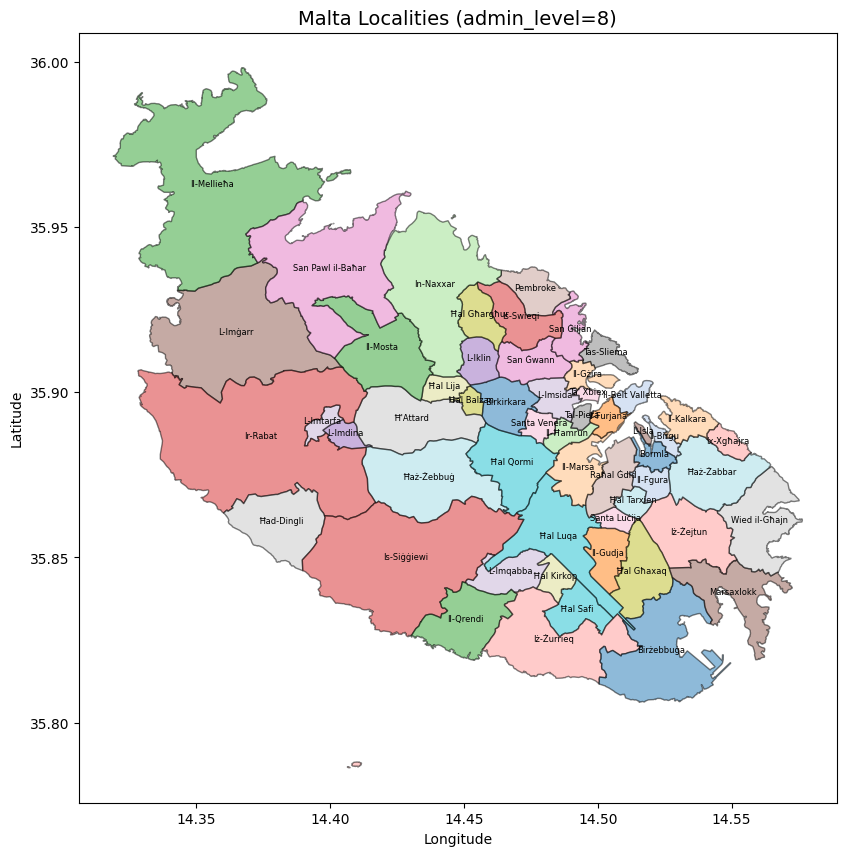

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
gdf_localities.plot(ax=ax, column="name", cmap="tab20", legend=False, alpha=0.5, edgecolor="black")
ax.set_title("Malta Localities (admin_level=8)", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Annotate locality names at polygon centroids
for idx, row in gdf_localities.iterrows():
    if row.geometry.is_empty:
        continue
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row["name"], fontsize=6, ha="center")

plt.show()


C:\Users\Pirot\AppData\Local\Temp\ipykernel_24188\16634428.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", gdf_localities_proj["color_id"].max() + 1)


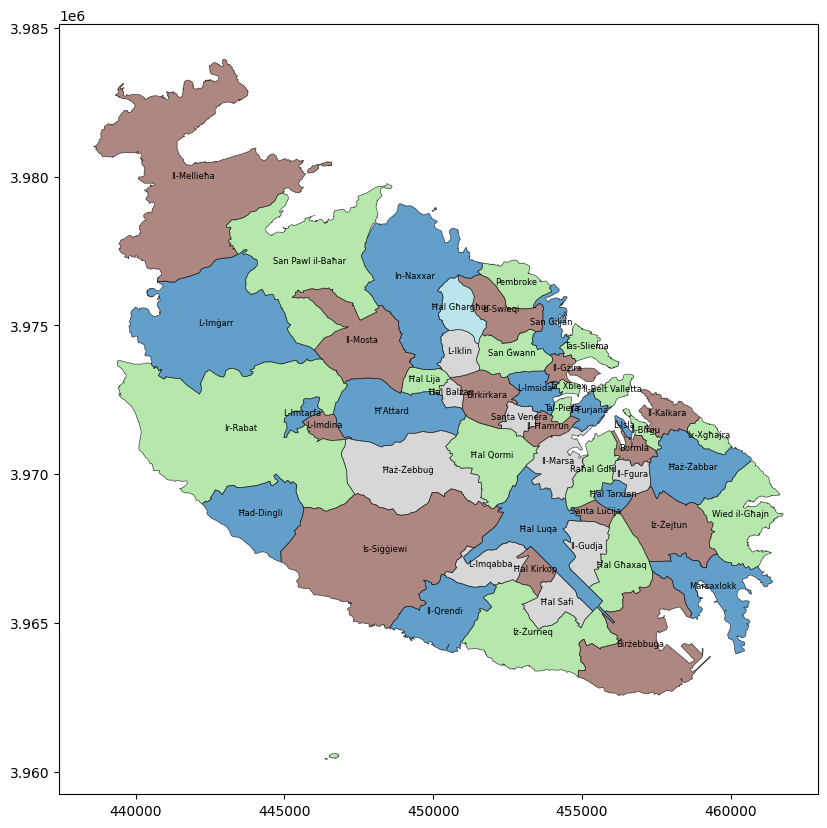

In [51]:
import matplotlib.pyplot as plt
import libpysal, networkx as nx, matplotlib.colors as mcolors

# Compute adjacency and greedy coloring
w = libpysal.weights.Rook.from_dataframe(gdf_localities_proj, ids=gdf_localities_proj.index)
G_adj = nx.Graph(w.neighbors)
coloring = nx.coloring.greedy_color(G_adj, strategy="largest_first")
gdf_localities_proj["color_id"] = gdf_localities_proj.index.map(coloring)

# Convert color IDs to hex colors
cmap = plt.cm.get_cmap("tab20", gdf_localities_proj["color_id"].max() + 1)
gdf_localities_proj["color"] = gdf_localities_proj["color_id"].apply(lambda x: mcolors.to_hex(cmap(x)))

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
gdf_localities_proj.plot(ax=ax, color=gdf_localities_proj["color"],alpha=0.7, edgecolor="black", linewidth=0.5)
for idx, row in gdf_localities_proj.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row["name"], fontsize=6, ha="center")
plt.show()


KeyError: 'color'

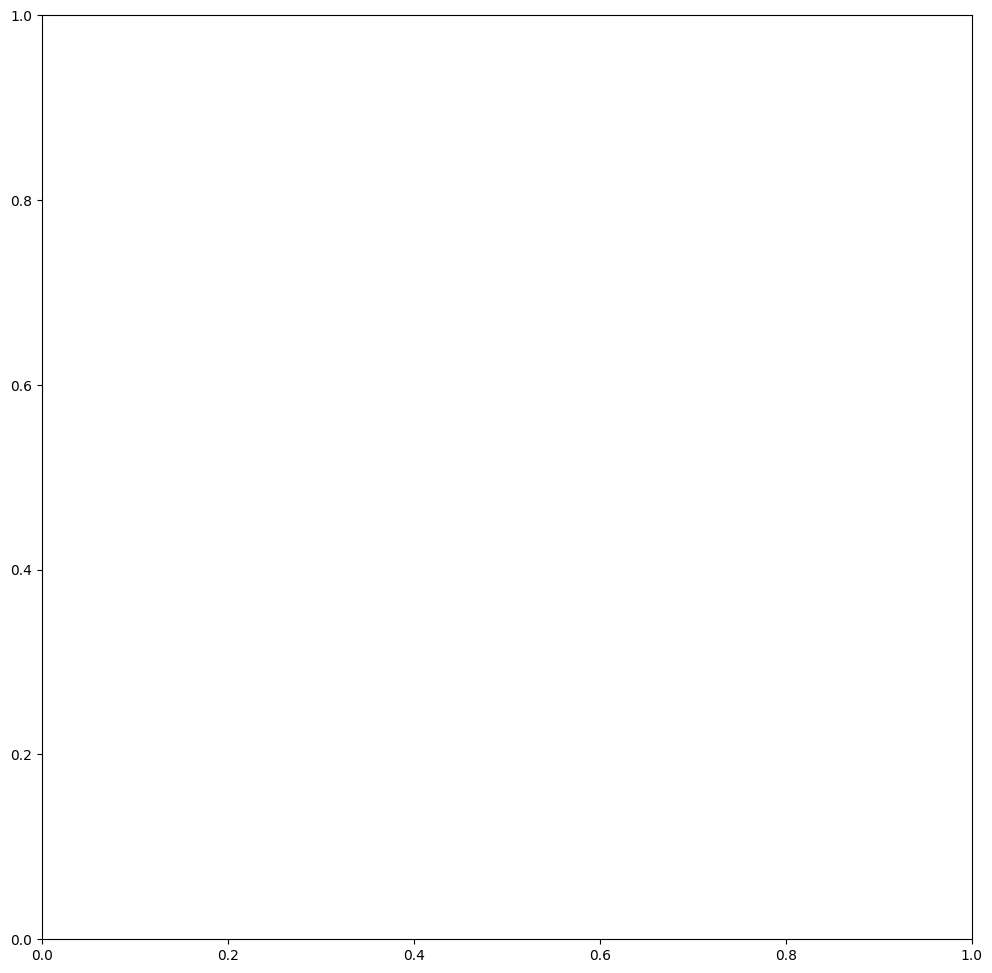

In [ ]:
import osmnx as ox
gdf_localities_proj = gdf_localities.to_crs(my_graph.G_master.graph["crs"])

# Plot the locality polygons
fig, ax = plt.subplots(figsize=(12, 12))
gdf_localities_proj.plot(ax=ax, cmap="tab20", edgecolor="gray", linewidth=5)

# Overlay the road network (projected to same CRS)
ox.plot_graph(
    my_graph.G_master,
    ax=ax,
    node_size=0,
    edge_color="black",
    bgcolor="white",
    show=False,
    close=False
)

ax.set_title("Malta: Road Network and Locality Boundaries", fontsize=14)
plt.show()


C:\Users\Pirot\AppData\Local\Temp\ipykernel_24188\3040289181.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", gdf_localities_proj["color_id"].max() + 1)


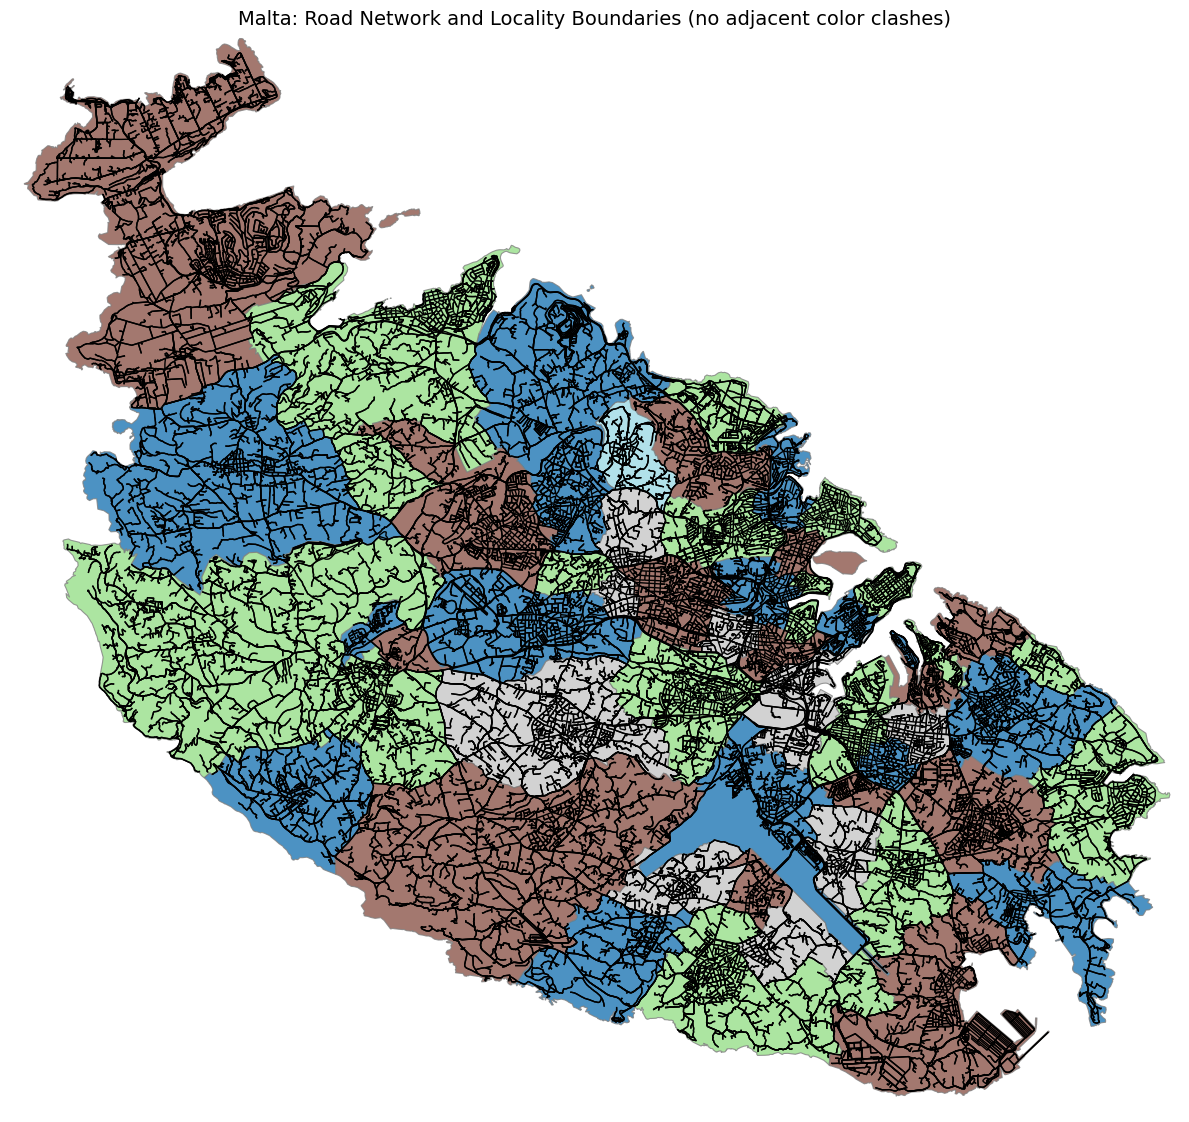

In [53]:
import osmnx as ox
import libpysal
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1) Ensure same CRS as the graph
gdf_localities_proj = gdf_localities.to_crs(my_graph.G_master.graph["crs"])

# 2) Build adjacency (Queen) and color with a greedy algorithm
w = libpysal.weights.Queen.from_dataframe(gdf_localities_proj, ids=gdf_localities_proj.index)
G_adj = nx.Graph(w.neighbors)
coloring = nx.coloring.greedy_color(G_adj, strategy="largest_first")
gdf_localities_proj["color_id"] = gdf_localities_proj.index.map(coloring)

# 3) Map color IDs → actual colors from a qualitative palette
cmap = plt.cm.get_cmap("tab20", gdf_localities_proj["color_id"].max() + 1)
gdf_localities_proj["color"] = gdf_localities_proj["color_id"].apply(lambda i: mcolors.to_hex(cmap(i)))

# 4) Plot polygons with assigned colors, then overlay the network
fig, ax = plt.subplots(figsize=(12, 12))
gdf_localities_proj.plot(
    ax=ax,
    color=gdf_localities_proj["color"],
    edgecolor="gray",
    linewidth=0.8,
    alpha=0.8
)

ox.plot_graph(
    my_graph.G_master,
    ax=ax,
    node_size=0,
    edge_color="black",
    bgcolor="white",
    show=False,
    close=False
)

ax.set_title("Malta: Road Network and Locality Boundaries (no adjacent color clashes)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()


# Topological Metrics

Evaluating how good a network is

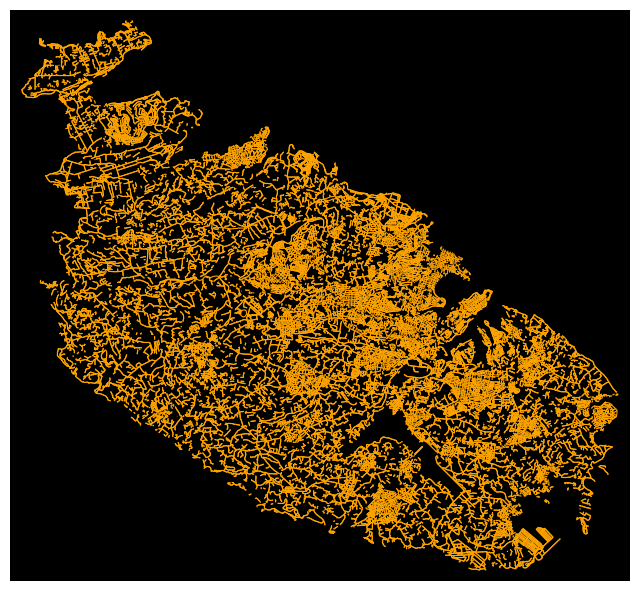

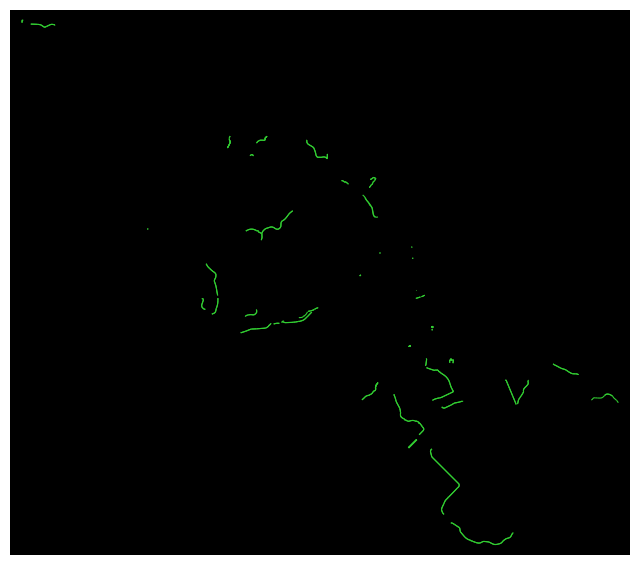

In [ ]:
fig, ax = ox.plot_graph(
    my_graph.make_bikeable_subgraph(my_graph.G_master),
    node_size=0,
    edge_color="orange",
    edge_linewidth=0.8,
    bgcolor="k"
)

fig, ax = ox.plot_graph(
    my_graph.make_protected_subgraph(my_graph.G_master),
    node_size=0,
    edge_color="limegreen",
    edge_linewidth=0.8,
    bgcolor="k"
)

In [ ]:
# Connectedness - describing whether the network forms a single, navigable system or remains fragmented into multiple component
def calc_connectedness(G:MultiDiGraph, G_lcc:MultiDiGraph) -> dict:
    num_components = nx.number_strongly_connected_components(G)
    lcc_length = float(sum(d.get("length", 0) for _, _, d in G_lcc.edges(data=True)))

    return {
        "num_components": num_components,
        "lcc_length": lcc_length,
    }


"""def calc_directness(Gb_lcc:MultiDiGraph, G_drive:MultiDiGraph, k = SAMPLE_K, seed=SEED):
    #TODO update when I actually have OD matrix data
    rng = random.Random(seed)

    nodes_b = list(Gb_lcc.nodes())
    if len(nodes_b) < 2:
        raise ValueError("Bike LCC has fewer than 2 nodes.")
    K_eff = min(k, len(nodes_b) * 5)  # keep reasonable number of pairs
    rng.seed(seed)
    ods = []
    while len(ods) < K_eff:
        o = rng.choice(nodes_b)
        d = rng.choice(nodes_b)
        if o != d:
            ods.append((o, d))
            
    pass"""

def calc_centrality(G_lcc:MultiDiGraph, k=SAMPLE_K, seed = SEED) -> dict:
    """Calculate comprehensive centrality metrics for cycling network assessment"""
    #NOTE full centrality is O(n^3), k is instead used to approximate

    num_nodes = len(G_lcc.nodes)
    k_eff = min(k, num_nodes)
    
    # Edge betweenness centrality - connectors for network resilience
    edge_between_cent = nx.edge_betweenness_centrality(G_lcc, weight="length", normalized=True, k=k_eff, seed = seed)
    mean_edge_between_cent = float(np.mean(list(edge_between_cent.values())))

    # betweenness centrality - measures how frequently a link lies on the shortest paths between all node pair
    node_between_cent = nx.betweenness_centrality(G_lcc, weight="length", normalized=True, k=k_eff, seed = seed)
    mean_node_between_cent = float(np.mean(list(node_between_cent.values())))

    #closeness_centrality - how close all other nodes are 
    node_close_cent = nx.closeness_centrality(G_lcc, distance="length")
    mean_node_close_cent = float(np.mean(list(node_close_cent.values())))

    degrees = [d for _, d in G_lcc.degree()]
    mean_degree = float(np.mean(degrees))
        
    return {
        "mean_edge_betweenness": mean_edge_between_cent,
        "mean_node_betweenness": mean_node_between_cent,
        "mean_node_closeness": mean_node_close_cent,
        "mean_degree": mean_degree,
    }


def network_evaluation(G:MultiDiGraph) -> dict:
    G_lcc = ox.truncate.largest_component(G, strongly=True) #NOTE strongly connected true since roads cycle infrastructure is directional

    connectedness = calc_connectedness(G, G_lcc)
    centrality  = calc_centrality(G_lcc)
    results = {**connectedness, **centrality}
    return results

In [ ]:
# Directness - measures how efficiently users can travel between two point

# Centrality
network_evaluation(my_graph.make_protected_subgraph(my_graph.G_master))
## Degree - number of connections per node

{'num_components': 71,
 'lcc_length': 102359918.91440608,
 'mean_edge_betweenness': 0.18888888888888886,
 'mean_node_betweenness': 0.33333333333333337,
 'mean_node_closeness': 6.188969074572137e-08,
 'mean_degree': 3.75}

# Optimisation Approaches 

## Heuristic Approaches

Centrality - betweeness and closeness

In [ ]:
def heuristic(G_master:MultiDiGraph, k=SAMPLE_K, seed=SEED):
    G_drive = my_graph.make_drive_subgraph(G_master)
    edges_between_cent = nx.edge_betweenness_centrality(G_drive, weight="length", normalized=True, k=k, seed=seed)
    max_between_cent_edge = max(edges_between_cent, key=edges_between_cent.get)
    print(max_between_cent_edge)
    
    u,v,k = max_between_cent_edge
    #print(f"edge before: {G_master[u][v][k]}")
    my_graph.reallocate_edge(G_master, max_between_cent_edge)
    #print(f"edge after: {G_master[u][v][k]}" )

(9250737080, 378205575, 0)
(9250737080, 378205575, 0)
(9250737080, 378205575, 0)
(9250737080, 378205575, 0)
(9250737080, 378205575, 0)
 
*** Profile stats marshalled to file 'C:\\Users\\Pirot\\AppData\\Local\\Temp\\tmpokq34ne7'.
Opening SnakeViz in a new tab...


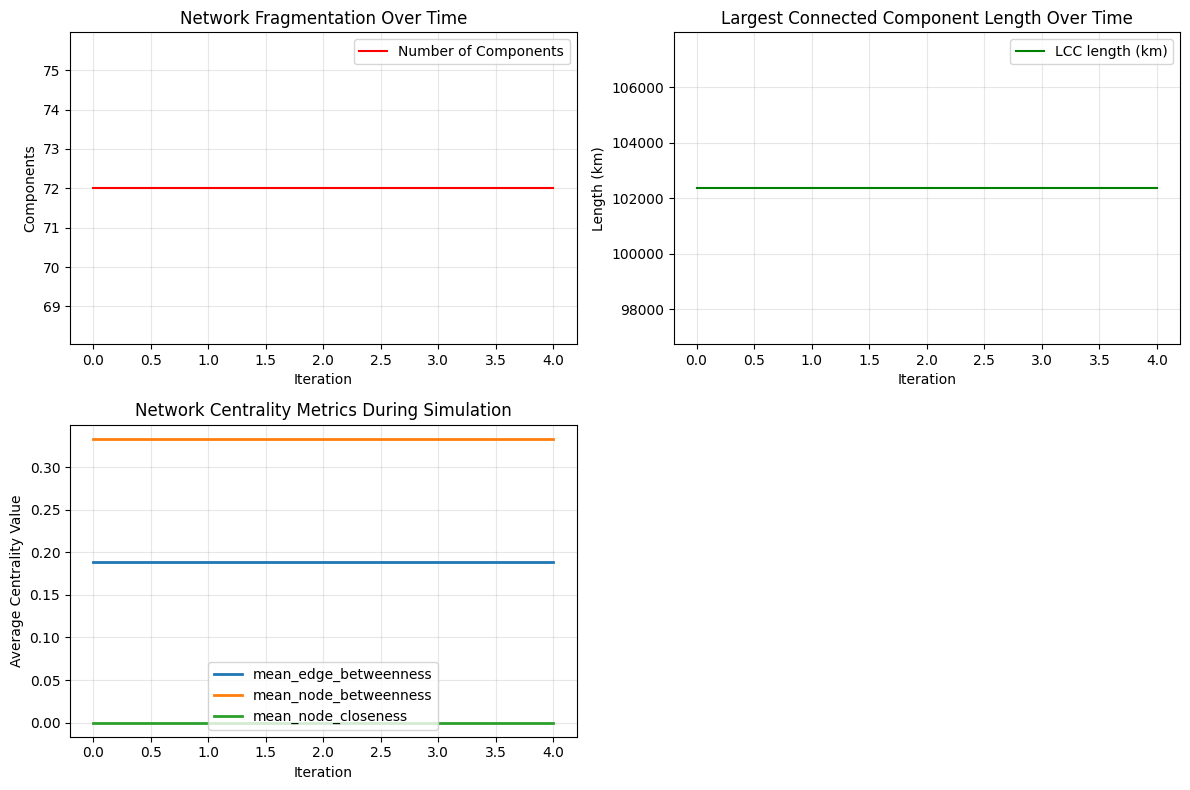

In [ ]:
def run_simulation(graphs:GraphManager):
    G_working = copy.deepcopy(graphs.G_master)

    evaluations = []
    for i in range(5):
        #print(f"{i}th iteration running...")
        #NOTE heuristic is taking too much time
        heuristic(G_working, k=10)
        #print("heuristic complete")

        protected_subgraph = graphs.make_protected_subgraph(G_working)
        #print("making protected subgraph")
        evaluation = network_evaluation(protected_subgraph)
        #print("evaluating protected subgraph")
        evaluations.append(evaluation)
    
    return evaluations

%snakeviz -t results = run_simulation(my_graph)

df_results = pd.DataFrame(results)
df_results.index.name = "iteration"

plotting.plot_evaluation(df_results)
